# 6 — Backtests

Consolidated backtesting chapter. Each part is self-contained (re-imports and re-loads its inputs) and runs top-to-bottom in sequence:

- **Part A — Static backtest (baseline):** fixed pairs, full-sample in-sample / out-of-sample evaluation of the baseline Kalman z-score signal.
- **Part B — Refined backtest:** the same fixed pairs with the risk-managed refined signal (dynamic z-score bands + volatility-based drawdown control).
- **Part C — Walk-forward backtest (static pair selection):** rolling-window evaluation while holding the pair set fixed — the honest out-of-sample robustness check for a fixed book.
- **Part D — Dynamic pair selection:** the pairs are re-selected every quarter from a rolling 12-month cointegration formation window, then compared head-to-head against the fixed book on the identical fold schedule.

The narrative arc is *static → walk-forward-static → dynamic*, where each step changes one variable, so any performance difference is attributable to that step.

---

# Part A — Static Backtest (Baseline)

In [1]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.config import *
from src.backtest import *
from src.bootstrap import *

In [2]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

In [3]:
# Load dictionaries from previous notebook
with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)

portfolio = pd.read_csv(PROJECT_ROOT / "data/portfolio")

In [4]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv(PROJECT_ROOT / "data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv(PROJECT_ROOT / "data/rf_oos",
                     index_col=0, parse_dates=True)

## Construct IS and OOS portfolios

In [5]:
weights   = portfolio.set_index("pair")["weight"].to_dict()
obs_cov   = OBS_COV

is_portfolio_dict  = {}
oos_portfolio_dict = {}

for strategy_name, signals_dict in is_results.items():
    pair_rets = {}
    for (pair_name, R), df in signals_dict.items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        # Net of transaction costs (15 bps/leg, see src/config.py)
        cost = leg_transaction_costs(df["position"])
        pair_rets[pair_name] = (df["strategy_ret"].fillna(0.0) - cost) * weights[pair_name]
    if pair_rets:
        is_portfolio_dict[strategy_name] = pd.DataFrame(pair_rets).sum(axis=1)

for strategy_name, signals_dict in oos_results.items():
    pair_rets = {}
    for (pair_name, R), df in signals_dict.items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        # Net of transaction costs (15 bps/leg, see src/config.py)
        cost = leg_transaction_costs(df["position"])
        pair_rets[pair_name] = (df["strategy_ret"].fillna(0.0) - cost) * weights[pair_name]
    if pair_rets:
        oos_portfolio_dict[strategy_name] = pd.DataFrame(pair_rets).sum(axis=1)

print("IS  strategies:", list(is_portfolio_dict.keys()))
print("OOS strategies:", list(oos_portfolio_dict.keys()))

IS  strategies: ['entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0', 'entry_2.5_exit_0.0', 'entry_2.5_exit_0.5', 'entry_2.5_exit_1.0']
OOS strategies: ['entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0', 'entry_2.5_exit_0.0', 'entry_2.5_exit_0.5', 'entry_2.5_exit_1.0']


## In-Sample Backtest

In [6]:
is_portfolio_rows = []

for strategy_name, ret in is_portfolio_dict.items():
    ret = ret.dropna()
    mean_ret = ret.mean()
    std_ret  = ret.std()
    sharpe   = mean_ret / std_ret if std_ret != 0 else np.nan

    is_portfolio_rows.append({
        "strategy":    strategy_name,
        "entry_z":     float(strategy_name.split("_")[1]),
        "exit_z":      float(strategy_name.split("_")[3]),
        "sharpe":      sharpe,
        "total_return": ret.sum(),
    })

is_portfolio_signals = pd.DataFrame(is_portfolio_rows)

In [7]:
is_sharpe_pivot = is_portfolio_signals.pivot_table(
    index="entry_z", columns="exit_z", values="sharpe"
)

is_return_pivot = is_portfolio_signals.pivot_table(
    index="entry_z", columns="exit_z", values="total_return"
)

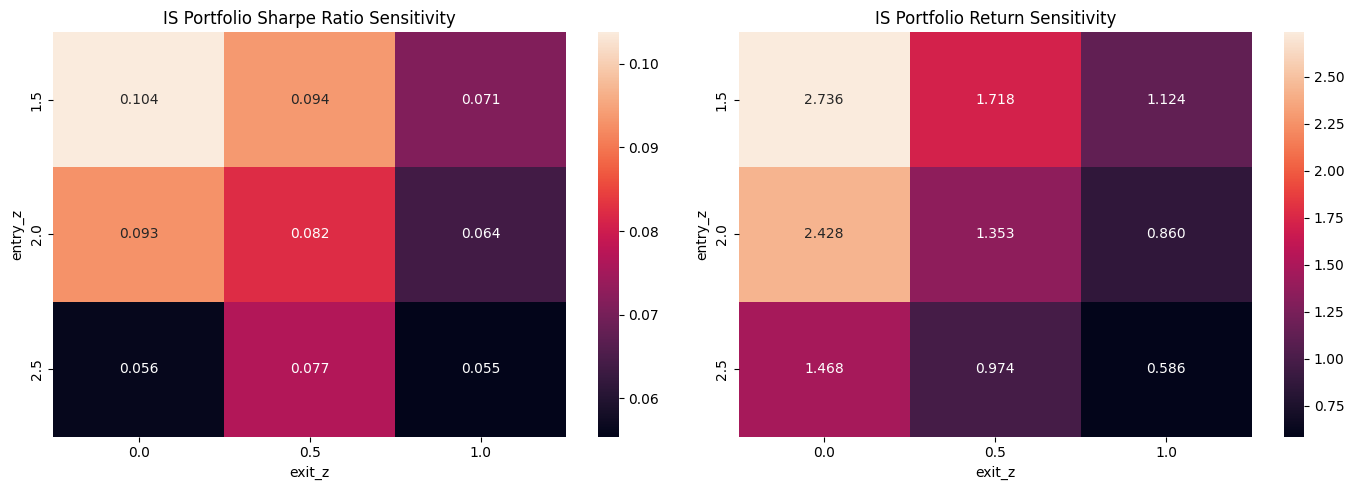

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    is_sharpe_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[0]
)

axes[0].set_title("IS Portfolio Sharpe Ratio Sensitivity")
axes[0].set_xlabel("exit_z")
axes[0].set_ylabel("entry_z")

sns.heatmap(
    is_return_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[1]
)

axes[1].set_title("IS Portfolio Return Sensitivity")
axes[1].set_xlabel("exit_z")
axes[1].set_ylabel("entry_z")

plt.tight_layout()
plt.show()

From our sensitivity analysis, we see it indicates that the strategy performs best using an entry threshold of 2.0 and an exit threshold of 0.0. This combination produces both the highest average Sharpe ratio and the highest average total return, suggesting that a moderate entry threshold provides the best balance between signal reliability and trade frequency. Lower entry thresholds may generate excessive trades based on weaker deviations, while higher thresholds may be too restrictive and reduce trading opportunities. The return heatmap also shows that exiting at 0.0 consistently outperforms exiting at 0.5 or 1.0, indicating that the strategy benefits from holding positions until the spread has fully reverted to its mean.

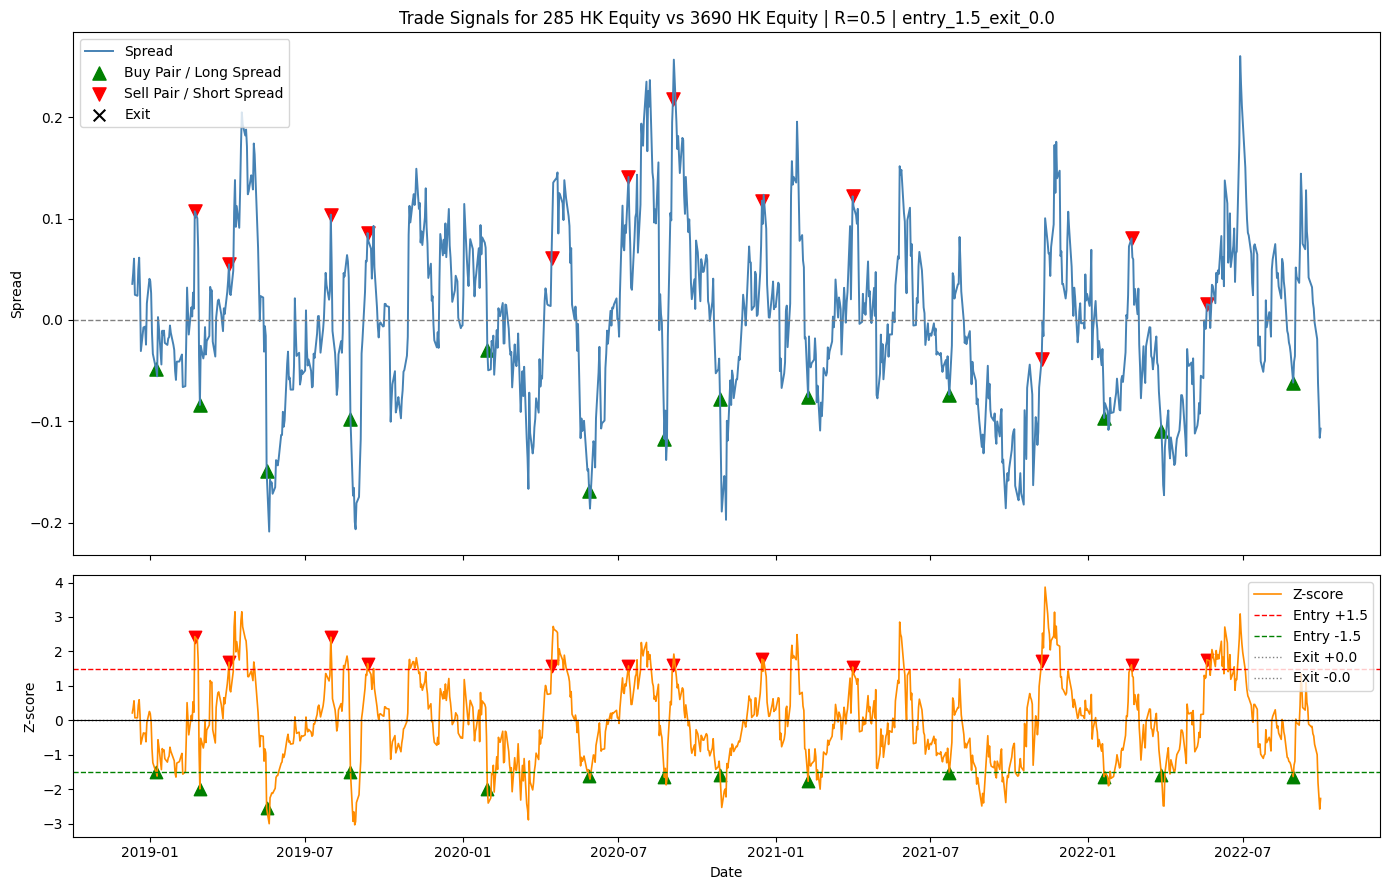

In [9]:
# An example of a pairs' trading signal 
strategy_name = sorted(is_results.keys())[0]
pair_name, obs_cov = next(iter(is_results[strategy_name].keys()))

plot_trade_signals(
    results_dict=is_results,
    strategy_name=strategy_name,
    pair_name=pair_name,
    obs_cov=obs_cov
)

### Performance metrics 

In [10]:
is_metrics  = performance_metrics(is_portfolio_dict["entry_1.5_exit_0.5"],  rf=rf_is, bootstrap_ci=True)

In [11]:
is_metrics

avg_return (%)                             0.0758
avg_excess_return (%)                      0.0843
annualised_sharpe        1.3500  [0.6243, 2.0244]
total_pnl                                  306.29
hit_rate (%)                                56.96
max_drawdown (%)                           -21.92
num_obs                                      1963
dtype: object

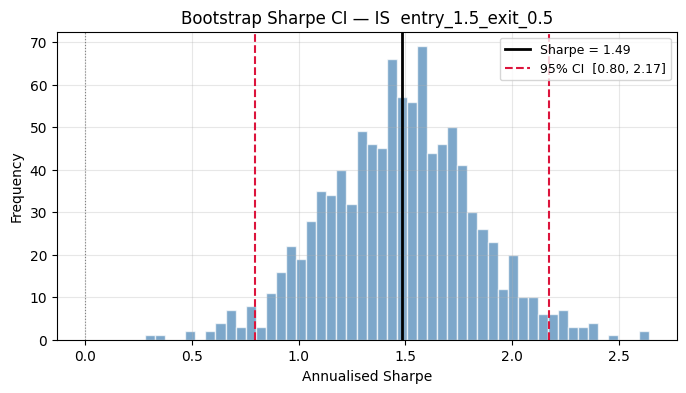

In [12]:
# Sharpe Ratio Bootstrapped Confidence Interval Plot
strategy_name = "entry_1.5_exit_0.5"

is_ci  = bootstrap_sharpe_ci(is_portfolio_dict[strategy_name],  seed=42)

plot_sharpe_ci(is_ci,  label=f"IS  {strategy_name}")
plt.show()

## OOS Backtest

### Performance Metrics

In [13]:
oos_metrics = performance_metrics(oos_portfolio_dict["entry_1.5_exit_0.5"], rf=rf_oos, bootstrap_ci=True)

In [14]:
oos_metrics

avg_return (%)                              0.0765
avg_excess_return (%)                       0.0642
annualised_sharpe        0.8073  [-0.1540, 1.8156]
total_pnl                                    78.77
hit_rate (%)                                 55.02
max_drawdown (%)                            -18.93
num_obs                                        848
dtype: object

In [15]:
pd.DataFrame([is_metrics, oos_metrics], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.0758,0.0843,"1.3500 [0.6243, 2.0244]",306.29,56.96,-21.92,1963
Out-of-Sample,0.0765,0.0642,"0.8073 [-0.1540, 1.8156]",78.77,55.02,-18.93,848


### IS and OOS PnL Performance

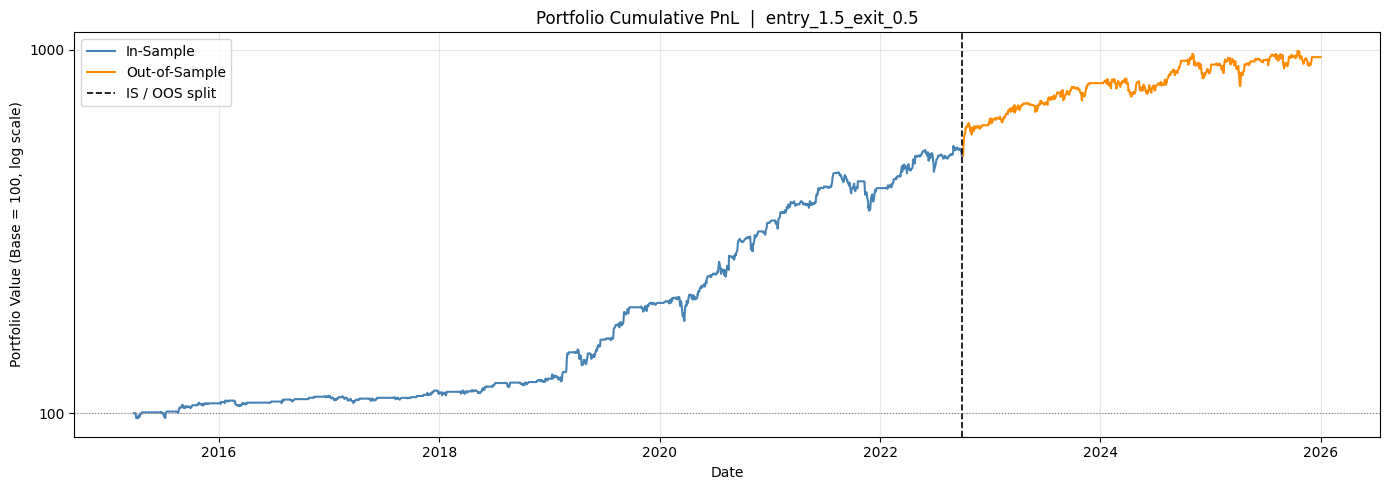

In [16]:
save_dir = PROJECT_ROOT / "outputs/trading_signal"
label = "cumulative_pnl_base"
os.makedirs(save_dir, exist_ok=True)

strategy_name = "entry_1.5_exit_0.5"

is_ret  = is_portfolio_dict[strategy_name].fillna(0)
oos_ret = oos_portfolio_dict[strategy_name].fillna(0)

is_cum  = 100 * (1 + is_ret).cumprod()
oos_cum = is_cum.iloc[-1] * (1 + oos_ret).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(is_cum.index,  is_cum,  color="steelblue", lw=1.5, label="In-Sample")
ax.plot(oos_cum.index, oos_cum, color="darkorange", lw=1.5, label="Out-of-Sample")
ax.plot([is_cum.index[-1], oos_cum.index[0]],
        [is_cum.iloc[-1],  oos_cum.iloc[0]], color="grey", lw=0.8)
ax.axvline(is_cum.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator()) 
ax.set_title(f"Portfolio Cumulative PnL  |  {strategy_name}")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / f"{label}_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
plt.show()

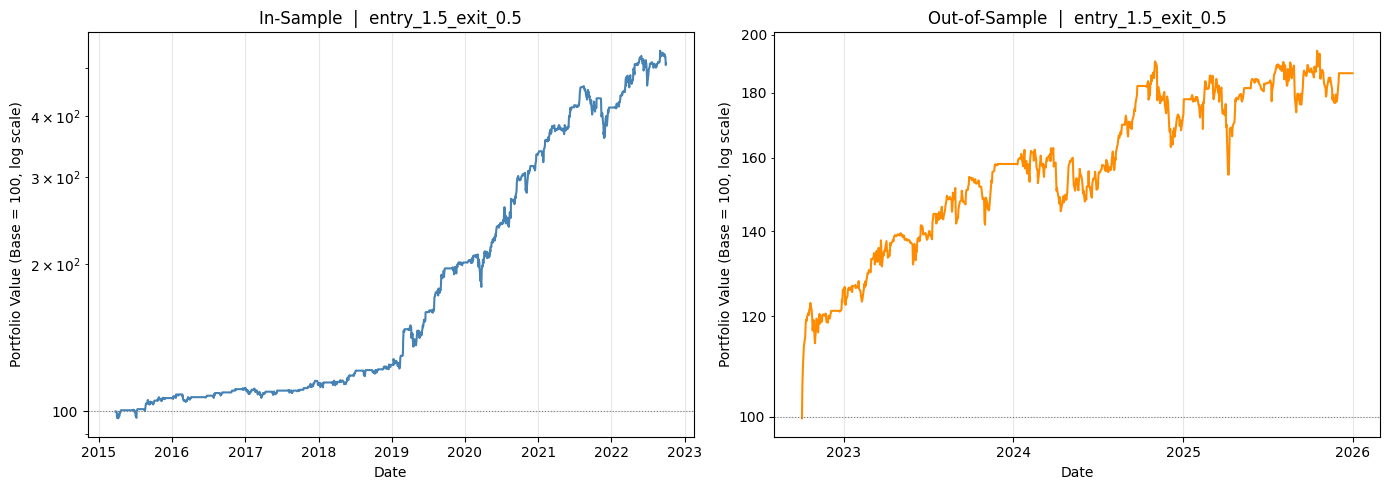

In [17]:
is_ret  = is_portfolio_dict[strategy_name].fillna(0)
oos_ret = oos_portfolio_dict[strategy_name].fillna(0)

is_cum  = 100 * (1 + is_ret).cumprod()
oos_cum = 100 * (1 + oos_ret).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(is_cum.index, is_cum, color="steelblue", lw=1.5)
axes[0].axhline(100, color="grey", linestyle=":", lw=0.8)
axes[0].set_title(f"In-Sample  |  {strategy_name}")
axes[0].set_ylabel("Portfolio Value (Base = 100, log scale)")
axes[0].set_xlabel("Date")
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].yaxis.get_major_formatter().set_scientific(False)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(oos_cum.index, oos_cum, color="darkorange", lw=1.5)
axes[1].axhline(100, color="grey", linestyle=":", lw=0.8)
axes[1].set_title(f"Out-of-Sample  |  {strategy_name}")
axes[1].set_ylabel("Portfolio Value (Base = 100, log scale)")
axes[1].set_xlabel("Date")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].yaxis.get_major_formatter().set_scientific(False)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].yaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Save metrics to compare against refined trading signal performance
with open(PROJECT_ROOT / "data/dictionaries/is_metrics.pkl", "wb") as f:
    pickle.dump(is_metrics, f) 

with open(PROJECT_ROOT / "data/dictionaries/oos_metrics.pkl", "wb") as f:
    pickle.dump(oos_metrics, f) 

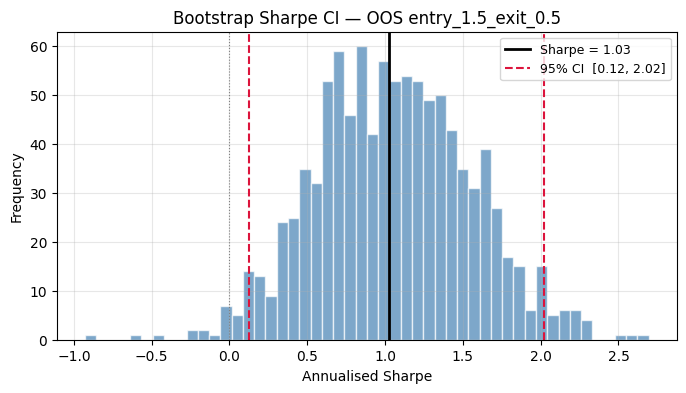

In [19]:
oos_ci = bootstrap_sharpe_ci(oos_portfolio_dict[strategy_name], seed=42)

plot_sharpe_ci(oos_ci, label=f"OOS {strategy_name}")
plt.show()

---

# Part B — Refined Backtest

In [20]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.config import *
from src.drawdown_optimisation import * 
from src.volatility_plot import *
from src.backtest import *
from src.refined_trading_signal import *
from src.bootstrap import *

In [21]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

In [22]:
# Load dictionaries from previous notebook
# In-Sample
with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/is_trading_signals.pkl", "rb") as f:
    is_trading_signals = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads_is.pkl", "rb") as f:
    dynamic_spreads_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)

# Out-Of-Sample
with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads_oos.pkl", "rb") as f:
    dynamic_spreads_oos = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_trading_signals.pkl", "rb") as f:
    oos_trading_signals = pickle.load(f)

# Baseline Trading Signal Performance
with open(PROJECT_ROOT / "data/dictionaries/is_metrics.pkl", "rb") as f:
    is_metrics = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_metrics.pkl", "rb") as f:
    oos_metrics = pickle.load(f)

# Portfolio
portfolio = pd.read_csv(PROJECT_ROOT / "data/portfolio")

# Load Portfolio Weighting
portfolio    = pd.read_csv(PROJECT_ROOT / "data/portfolio")
portfolio_pairs = set(portfolio["pair"])

# IS & OOS Portfolios
with open(PROJECT_ROOT / "data/portfolio_is.pkl", "rb") as f:
    portfolio_is = pickle.load(f)
with open(PROJECT_ROOT / "data/portfolio_oos.pkl", "rb") as f:
    portfolio_oos = pickle.load(f)

In [23]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv(PROJECT_ROOT / "data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv(PROJECT_ROOT / "data/rf_oos",
                     index_col=0, parse_dates=True)

# Enhanced Trading Signal Workflow 
1) Estimate Volatility using the return of the spread at time $t-i$
2) Calculate maximum drawdown threshold based off of the spread's volatlity 
3) Adjust the trading signals accordingly with the updated risk parameters and dynamic z-score bands

## Estimated Volatility Formula (*using EWMA*)
Calculated in calculate_vol function:
$$
\hat{\sigma_t}=\sqrt{\frac{\sum_{i=0}^tw_i(r_{t-i}-\mu_t)^2}{\sum_{i=0}^tw_i}}
$$

## Drawdown Threshold Formula
Calculated in drawdown_thresholds function:
$$
\text{Drawdown}=k_{m}\times\sigma_{i,t}\times\sqrt{H}
$$

Where:
- m is either the volatility multiplier coefficient for **reducing** position size or **closing** a position
- $\sigma_{i,t}$ is the estimated volatility from above for pair i
- H is the holding period (which we have fixed to 10 days for simplicity) 

In [24]:
is_extraction = extractor(is_results)
oos_extraction = extractor(oos_results)

In [25]:
is_extraction.head()

,date,strategy,pair,obs_cov,spread_t,position,spread_change,strategy_ret
1,2018-12-12,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.046180,0.0,0.010591,0.0
2,2018-12-13,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.060469,0.0,0.014289,0.0
3,2018-12-14,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.024826,0.0,-0.035644,-0.0
4,2018-12-17,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.023848,0.0,-0.000978,-0.0
5,2018-12-18,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.049768,0.0,0.025920,0.0


In [26]:
oos_extraction.head()

,date,strategy,pair,obs_cov,spread_t,position,spread_change,strategy_ret
1,2022-10-04,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.026958,1.0,-0.026610,-0.026610
2,2022-10-05,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.049380,1.0,0.022423,0.022423
3,2022-10-06,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,0.008386,1.0,-0.040995,-0.040995
4,2022-10-07,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,-0.013620,1.0,-0.022005,-0.022005
5,2022-10-10,entry_1.5_exit_0.0,285 HK Equity vs 3690 HK Equity,0.5,-0.075512,1.0,-0.061892,-0.061892


In [27]:
is_volatility = pair_volatility(is_extraction)
is_drawdown_values = drawdown_thresholds(is_volatility)

oos_volatility = pair_volatility(oos_extraction)
oos_drawdown_values = drawdown_thresholds(oos_volatility)

In [28]:
# Portfolio Drawdown Values
# In-Sample
strategy_name = "entry_1.5_exit_0.5"

drawdown_thresholds_is = is_drawdown_values[
    is_drawdown_values["strategy"] == strategy_name
][["date", "pair", "obs_cov", "reduce_drawdown_threshold", "close_drawdown_threshold"]]

# Out-of-Sample
drawdown_thresholds_oos = oos_drawdown_values[
    oos_drawdown_values["strategy"] == strategy_name
][["date", "pair", "obs_cov", "reduce_drawdown_threshold", "close_drawdown_threshold"]]

## Generating Refined Trading Signals

In [29]:
weights = portfolio.set_index("pair")["weight"].to_dict()
portfolio_pairs = set(portfolio["pair"])

dynamic_details_portfolio_is = {
    k: v for k, v in dynamic_details_is.items()
    if k[0] in portfolio_pairs
}

dynamic_details_portfolio_oos = {
    k: v for k, v in dynamic_details_oos.items()
    if k[0] in portfolio_pairs
}

In [30]:
is_signals_df  = generate_refined_kalman_signals_1(
    dynamic_details     = dynamic_details_portfolio_is,
    drawdown_thresholds = drawdown_thresholds_is   
)

oos_signals_df = generate_refined_kalman_signals_1(
    dynamic_details     = dynamic_details_portfolio_oos,
    drawdown_thresholds = drawdown_thresholds_oos
)

In [31]:
is_signals_df.head()

,y,x,alpha_t,beta_t,spread_t,obs_cov,rolling_mean,rolling_std,zscore,upper_band,...,trade_equity,running_peak,trade_drawdown,risk_state,z_window,band_window,upper_quantile,lower_quantile,exit_z,reduced_exposure
date,,,,,,,,,,,,,,,,,,,,,
2019-06-05,2.353278,4.088494,0.171742,0.555754,-0.090662,0.5,0.019429,0.112332,-0.980049,1.152011,...,0.0,0.0,0.0,flat,60,126,0.8,0.2,0.5,0.5
2019-06-06,2.332144,4.088494,0.172214,0.554058,-0.105332,0.5,0.017187,0.113470,-1.079740,1.152011,...,0.0,0.0,0.0,flat,60,126,0.8,0.2,0.5,0.5
2019-06-07,2.332144,4.088494,0.172613,0.552471,-0.099242,0.5,0.015889,0.114361,-1.006732,1.152011,...,0.0,0.0,0.0,flat,60,126,0.8,0.2,0.5,0.5
2019-06-10,2.390596,4.097672,0.172928,0.551744,-0.043197,0.5,0.015770,0.114419,-0.515361,1.152011,...,0.0,0.0,0.0,flat,60,126,0.8,0.2,0.5,0.5
2019-06-11,2.410542,4.115780,0.173364,0.551164,-0.031293,0.5,0.015214,0.114568,-0.405926,1.152011,...,0.0,0.0,0.0,flat,60,126,0.8,0.2,0.5,0.5


In [32]:
portfolio  = pd.read_csv(PROJECT_ROOT / "data/portfolio")
weights    = portfolio.set_index("pair")["weight"].to_dict()
obs_cov    = OBS_COV

def aggregate_refined_portfolio(signals_df, weights, obs_cov):
    filtered = signals_df[
        (np.isclose(signals_df["obs_cov"], obs_cov)) &
        (signals_df["pair"].isin(weights))
    ].copy()

    filtered["spread_change"] = filtered.groupby("pair")["spread_t"].diff()
    filtered["gross_ret"]     = filtered["active_position"] * filtered["spread_change"]
    # Net of transaction costs (15 bps/leg, see src/config.py)
    filtered["tc"]            = filtered.groupby("pair")["active_position"].transform(leg_transaction_costs)
    filtered["strategy_ret"]  = (filtered["gross_ret"] - filtered["tc"]) * filtered["pair"].map(weights)

    return filtered.groupby(filtered.index)["strategy_ret"].sum()

is_portfolio_ret  = aggregate_refined_portfolio(is_signals_df,  weights, obs_cov)
oos_portfolio_ret = aggregate_refined_portfolio(oos_signals_df, weights, obs_cov)

In [33]:
is_refined_metrics  = performance_metrics(is_portfolio_ret,  rf=rf_is, bootstrap_ci=True)
oos_refined_metrics = performance_metrics(oos_portfolio_ret, rf=rf_oos, bootstrap_ci=True)

pd.DataFrame([is_refined_metrics, oos_refined_metrics], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.0657,0.0698,"1.0480 [0.2744, 1.7689]",203.52,54.42,-27.07,1837
Out-of-Sample,0.0065,-0.0068,"-0.0803 [-1.1150, 0.9483]",-1.69,50.17,-27.82,663


In [34]:
# Comparison table between baseline and refined
comparison = pd.concat([
    pd.DataFrame([is_metrics, oos_metrics], index=["IS", "OOS"]).add_prefix("baseline_"),
    pd.DataFrame([is_refined_metrics, oos_refined_metrics],  index=["IS", "OOS"]).add_prefix("refined_"),
], axis=1)

comparison

,baseline_avg_return (%),baseline_avg_excess_return (%),baseline_annualised_sharpe,baseline_total_pnl,baseline_hit_rate (%),baseline_max_drawdown (%),baseline_num_obs,refined_avg_return (%),refined_avg_excess_return (%),refined_annualised_sharpe,refined_total_pnl,refined_hit_rate (%),refined_max_drawdown (%),refined_num_obs
IS,0.0758,0.0843,"1.3500 [0.6243, 2.0244]",306.29,56.96,-21.92,1963,0.0657,0.0698,"1.0480 [0.2744, 1.7689]",203.52,54.42,-27.07,1837
OOS,0.0765,0.0642,"0.8073 [-0.1540, 1.8156]",78.77,55.02,-18.93,848,0.0065,-0.0068,"-0.0803 [-1.1150, 0.9483]",-1.69,50.17,-27.82,663


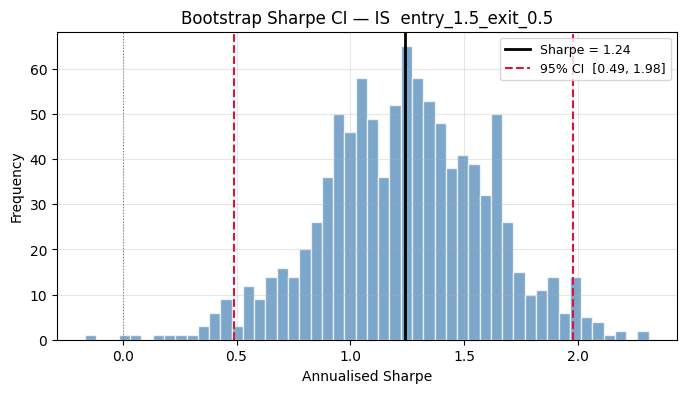

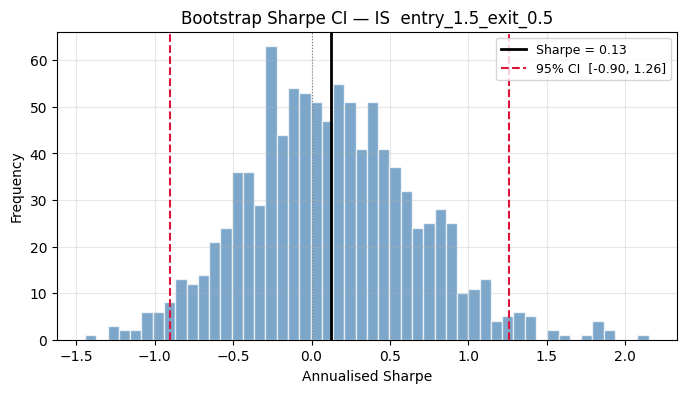

In [35]:
# Sharpe Ratio Bootstrapped Confidence Interval Plot
strategy_name = "entry_1.5_exit_0.5"

is_ci  = bootstrap_sharpe_ci(is_portfolio_ret,  seed=42)
oos_ci = bootstrap_sharpe_ci(oos_portfolio_ret, seed=42)

plot_sharpe_ci(is_ci,  label=f"IS  {strategy_name}")
plt.show()
plot_sharpe_ci(oos_ci,  label=f"IS  {strategy_name}")
plt.show()

## Refined Trading Signal w/o Drawdown Parameter

In [36]:
is_signals_2_df = generate_refined_kalman_signals_2(
    dynamic_details_portfolio_is,
    use_fixed_bands=False,
    upper_quantile=0.80,
    lower_quantile=0.20
)

oos_signals_2_df = generate_refined_kalman_signals_2(
    dynamic_details = dynamic_details_portfolio_oos,
    use_fixed_bands=False,
    upper_quantile=0.80,
    lower_quantile=0.20
)

In [37]:
is_portfolio_ret_2  = aggregate_refined_portfolio(is_signals_2_df,  weights, obs_cov)
oos_portfolio_ret_2 = aggregate_refined_portfolio(oos_signals_2_df, weights, obs_cov)

In [38]:
is_refined_metrics_2  = performance_metrics(is_portfolio_ret_2,  rf=rf_is, bootstrap_ci=True)
oos_refined_metrics_2 = performance_metrics(oos_portfolio_ret_2, rf=rf_oos, bootstrap_ci=True)

pd.DataFrame([is_refined_metrics_2, oos_refined_metrics_2], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.0671,0.0713,"1.0657 [0.2980, 1.7694]",211.21,54.10,-25.43,1837
Out-of-Sample,0.0052,-0.0081,"-0.0941 [-1.1152, 1.0365]",-2.66,49.59,-28.44,663


In [39]:
# Comparison table between baseline and refined (w/o drawdown)
comparison_2 = pd.concat([
    pd.DataFrame([is_metrics, oos_metrics], index=["IS", "OOS"]).add_prefix("baseline_"),
    pd.DataFrame([is_refined_metrics_2, oos_refined_metrics_2],  index=["IS", "OOS"]).add_prefix("refined_"),
], axis=1)

comparison_2

,baseline_avg_return (%),baseline_avg_excess_return (%),baseline_annualised_sharpe,baseline_total_pnl,baseline_hit_rate (%),baseline_max_drawdown (%),baseline_num_obs,refined_avg_return (%),refined_avg_excess_return (%),refined_annualised_sharpe,refined_total_pnl,refined_hit_rate (%),refined_max_drawdown (%),refined_num_obs
IS,0.0758,0.0843,"1.3500 [0.6243, 2.0244]",306.29,56.96,-21.92,1963,0.0671,0.0713,"1.0657 [0.2980, 1.7694]",211.21,54.10,-25.43,1837
OOS,0.0765,0.0642,"0.8073 [-0.1540, 1.8156]",78.77,55.02,-18.93,848,0.0052,-0.0081,"-0.0941 [-1.1152, 1.0365]",-2.66,49.59,-28.44,663


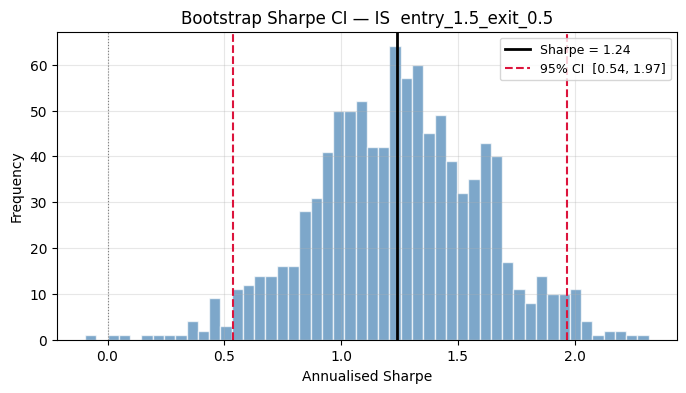

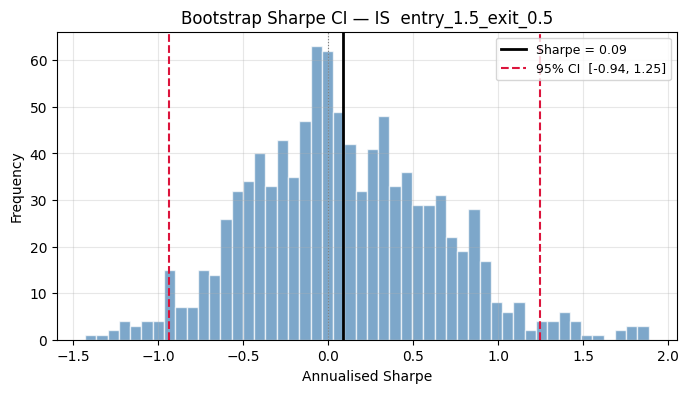

In [40]:
# Sharpe Ratio Bootstrapped Confidence Interval Plot
strategy_name = "entry_1.5_exit_0.5"

is_ci  = bootstrap_sharpe_ci(is_portfolio_ret_2,  seed=42)
oos_ci = bootstrap_sharpe_ci(oos_portfolio_ret_2, seed=42)

plot_sharpe_ci(is_ci,  label=f"IS  {strategy_name}")
plt.show()
plot_sharpe_ci(oos_ci,  label=f"IS  {strategy_name}")
plt.show()

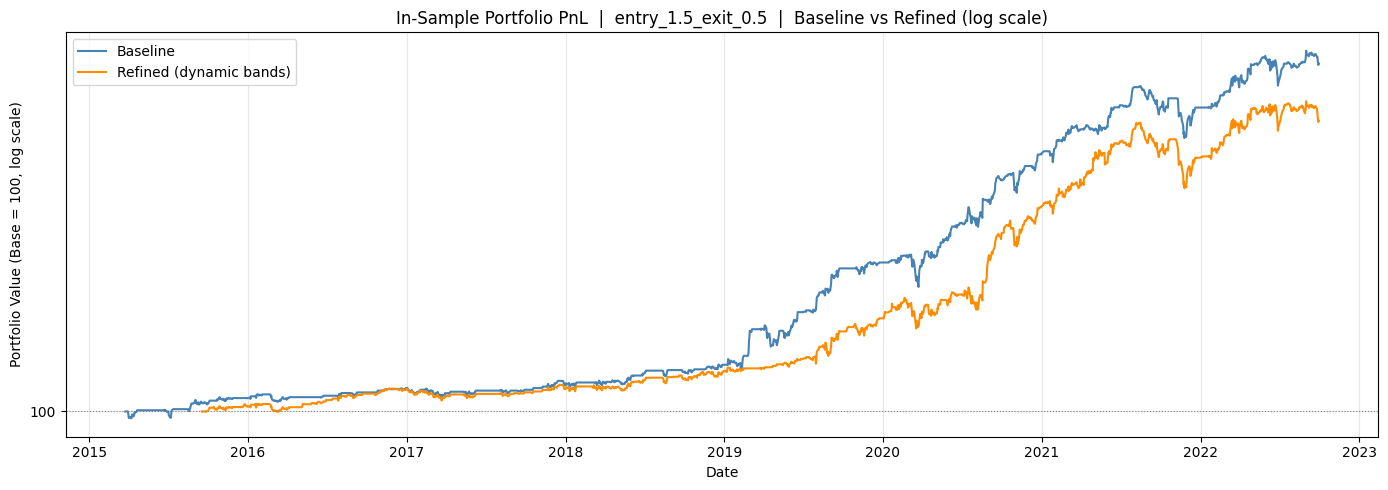

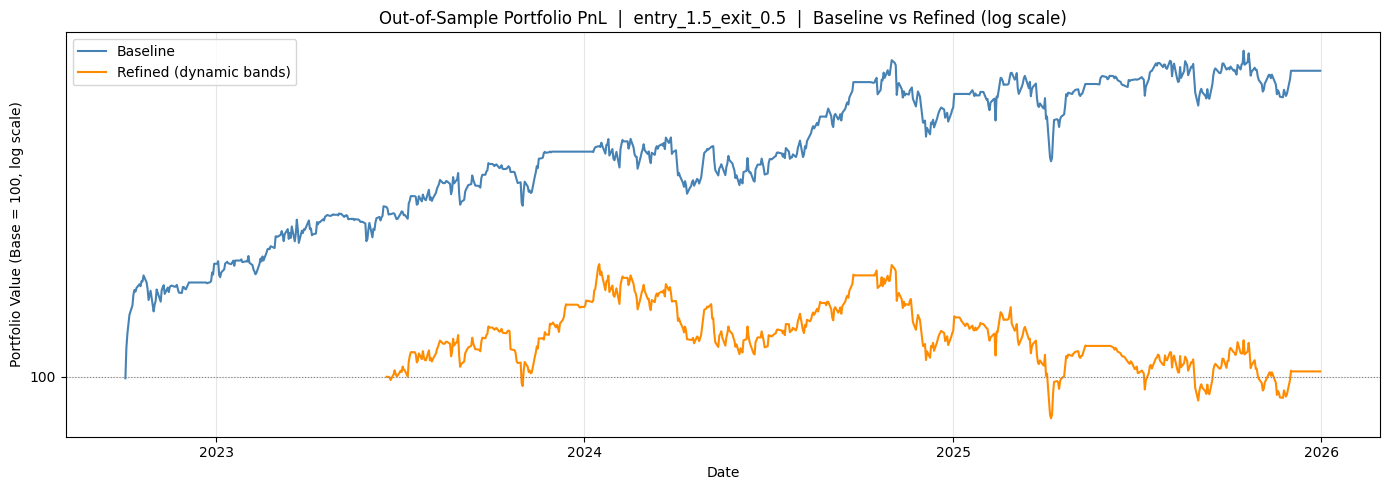

In [41]:
save_dir = PROJECT_ROOT / "outputs/refined_trading_signal"
os.makedirs(save_dir, exist_ok=True)

def build_portfolio_ret(results, strategy_name, weights, obs_cov):
    pair_rets = {}
    for (pair_name, R), df in results[strategy_name].items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        # Net of transaction costs (15 bps/leg, see src/config.py)
        cost = leg_transaction_costs(df["position"])
        pair_rets[pair_name] = (df["strategy_ret"].fillna(0.0) - cost) * weights[pair_name]
    return pd.DataFrame(pair_rets).sum(axis=1)

is_baseline  = build_portfolio_ret(is_results,  strategy_name, weights, obs_cov)
oos_baseline = build_portfolio_ret(oos_results, strategy_name, weights, obs_cov)

is_cum_base  = 100 * (1 + is_baseline.fillna(0)).cumprod()
oos_cum_base = 100 * (1 + oos_baseline.fillna(0)).cumprod()
is_cum_ref   = 100 * (1 + is_portfolio_ret.fillna(0)).cumprod()
oos_cum_ref  = 100 * (1 + oos_portfolio_ret.fillna(0)).cumprod()

for cum_base, cum_ref, label in [
    (is_cum_base,  is_cum_ref,  "In_Sample"),
    (oos_cum_base, oos_cum_ref, "Out_of_Sample"),
]:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cum_base.index, cum_base, color="steelblue",  lw=1.5, label="Baseline")
    ax.plot(cum_ref.index,  cum_ref,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
    ax.axhline(100, color="grey", linestyle=":", lw=0.8)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.set_title(f"{label.replace('_', '-')} Portfolio PnL  |  {strategy_name}  |  Baseline vs Refined (log scale)")
    ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_dir / f"{label}_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
    plt.show()

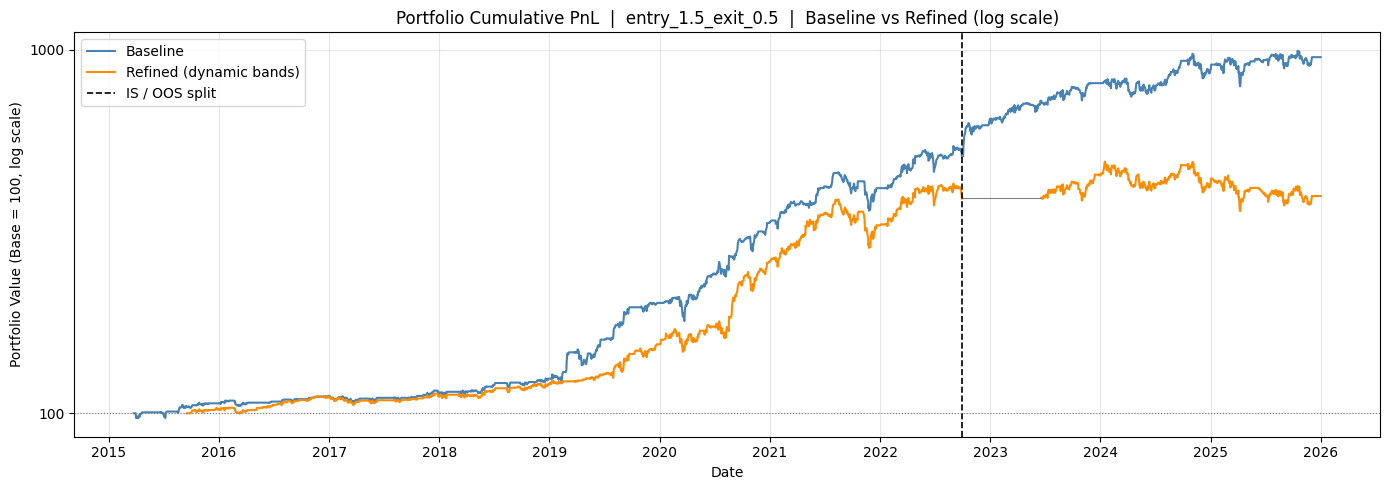

In [42]:
oos_cum_base_cont = is_cum_base.iloc[-1] * (1 + oos_baseline.fillna(0)).cumprod()
oos_cum_ref_cont  = is_cum_ref.iloc[-1]  * (1 + oos_portfolio_ret.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
for is_cum, oos_cum, color, label in [
    (is_cum_base, oos_cum_base_cont, "steelblue",  "Baseline"),
    (is_cum_ref,  oos_cum_ref_cont,  "darkorange", "Refined (dynamic bands)"),
]:
    ax.plot(is_cum.index,  is_cum,  color=color, lw=1.5, label=label)
    ax.plot(oos_cum.index, oos_cum, color=color, lw=1.5)
    ax.plot([is_cum.index[-1], oos_cum.index[0]],
            [is_cum.iloc[-1],  oos_cum.iloc[0]], color="grey", lw=0.8)

ax.axvline(is_cum_base.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title(f"Portfolio Cumulative PnL  |  {strategy_name}  |  Baseline vs Refined (log scale)")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / f"Combined_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
plt.show()

---

# Part C — Walk-Forward Backtest (Static Pair Selection)

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.trading_signal import *
from src.backtest import *
from src.rolling_backtest import *
from src.bootstrap import *

In [44]:
# Load Kalman details and combine IS + OOS into one continuous dict
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)

dynamic_details_full = {}
for key in dynamic_details_oos:
    is_df  = dynamic_details_is.get(key, pd.DataFrame())
    oos_df = dynamic_details_oos[key]
    dynamic_details_full[key] = pd.concat([is_df, oos_df]).sort_index()

In [45]:
# Filter to portfolio pairs
portfolio       = pd.read_csv(PROJECT_ROOT / "data/portfolio")
weights         = portfolio.set_index("pair")["weight"].to_dict()
portfolio_pairs = set(portfolio["pair"])

dynamic_details_full = {k: v for k, v in dynamic_details_full.items() if k[0] in portfolio_pairs}

# Combined risk-free rate
rf_is   = pd.read_csv(PROJECT_ROOT / "data/rf_is",  index_col=0, parse_dates=True)
rf_oos  = pd.read_csv(PROJECT_ROOT / "data/rf_oos", index_col=0, parse_dates=True)
rf_full = pd.concat([rf_is, rf_oos]).sort_index()

print("Pairs:", sorted(set(k[0] for k in dynamic_details_full)))
ref = dynamic_details_full[next(iter(dynamic_details_full))]
print("Date range:", ref.index[0].date(), "→", ref.index[-1].date())

Pairs: ['1818 HK Equity vs 1921 HK Equity', '2386 HK Equity vs 386 HK Equity', '285 HK Equity vs 3690 HK Equity']
Date range: 2018-09-19 → 2025-12-31


In [46]:
entry_values = [1.0, 1.5, 2.0]
exit_values  = [0.0, 0.5, 1.0]

rolling_results = {}

for e in entry_values:
    for x in exit_values:
        key = f"entry_{e}_exit_{x}"
        rolling_results[key] = walk_forward_backtest(
            dynamic_details = dynamic_details_full,
            weights         = weights,
            entry_z         = e,
            exit_z          = x,
            obs_cov         = 1.0,
            is_window       = 262,
            oos_step        = 63,
        )

print("Strategies computed:", list(rolling_results.keys()))

Strategies computed: ['entry_1.0_exit_0.0', 'entry_1.0_exit_0.5', 'entry_1.0_exit_1.0', 'entry_1.5_exit_0.0', 'entry_1.5_exit_0.5', 'entry_1.5_exit_1.0', 'entry_2.0_exit_0.0', 'entry_2.0_exit_0.5', 'entry_2.0_exit_1.0']


In [47]:
# Performance metrics for all strategies
metrics_rows = []
for key, ret in rolling_results.items():
    rf_aligned = rf_full.reindex(ret.index).ffill()
    m = performance_metrics(ret, rf=rf_aligned, bootstrap_ci = True)
    m["strategy"] = key
    metrics_rows.append(m)

rolling_metrics_df = pd.DataFrame(metrics_rows).set_index("strategy")
rolling_metrics_df

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
strategy,,,,,,,
entry_1.0_exit_0.0,0.2382,0.2312,"1.7533 [1.0950, 2.3865]",3406.77,57.45,-23.89,1638
entry_1.0_exit_0.5,0.1553,0.1483,"1.4616 [0.7614, 2.1150]",936.75,57.72,-21.83,1638
entry_1.0_exit_1.0,0.1341,0.1271,"1.3526 [0.6504, 1.9414]",655.51,58.55,-20.29,1638
entry_1.5_exit_0.0,0.1848,0.1778,"1.5059 [0.7189, 2.2273]",1449.74,56.53,-23.87,1638
entry_1.5_exit_0.5,0.1353,0.1283,"1.3699 [0.7185, 1.9795]",670.93,57.83,-21.16,1638
entry_1.5_exit_1.0,0.1013,0.0943,"1.0985 [0.4495, 1.7194]",354.77,58.44,-17.64,1638
entry_2.0_exit_0.0,0.1909,0.1838,"1.4151 [0.7376, 2.0806]",1533.05,55.62,-21.52,1638
entry_2.0_exit_0.5,0.1141,0.1070,"1.2191 [0.5645, 1.8108]",456.62,57.41,-17.51,1638
entry_2.0_exit_1.0,0.0901,0.0830,"1.0636 [0.4497, 1.6251]",288.58,60.32,-14.98,1638


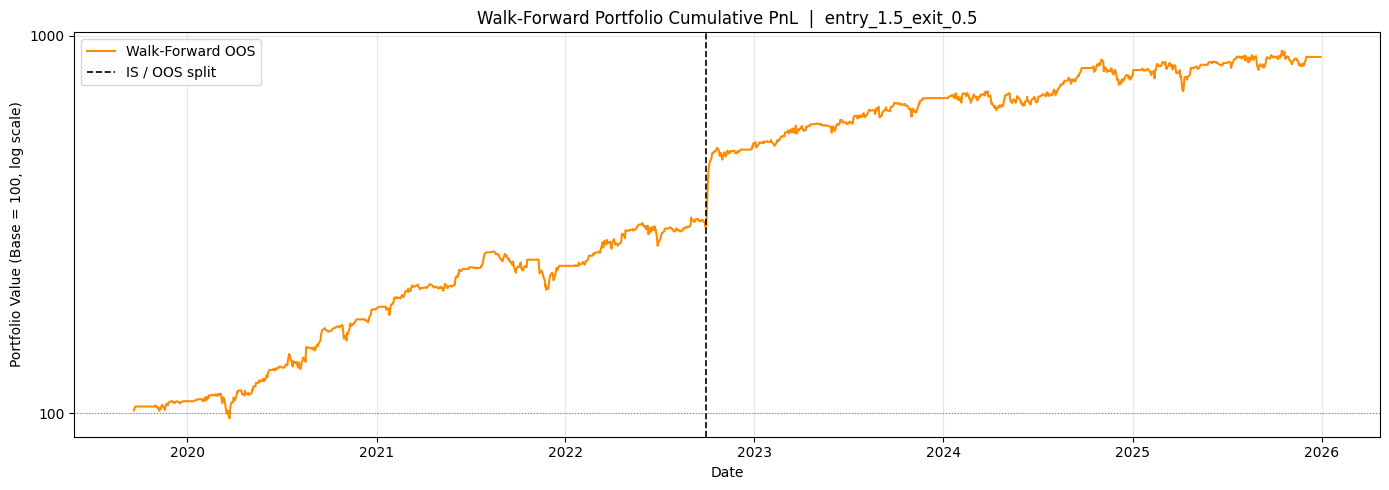

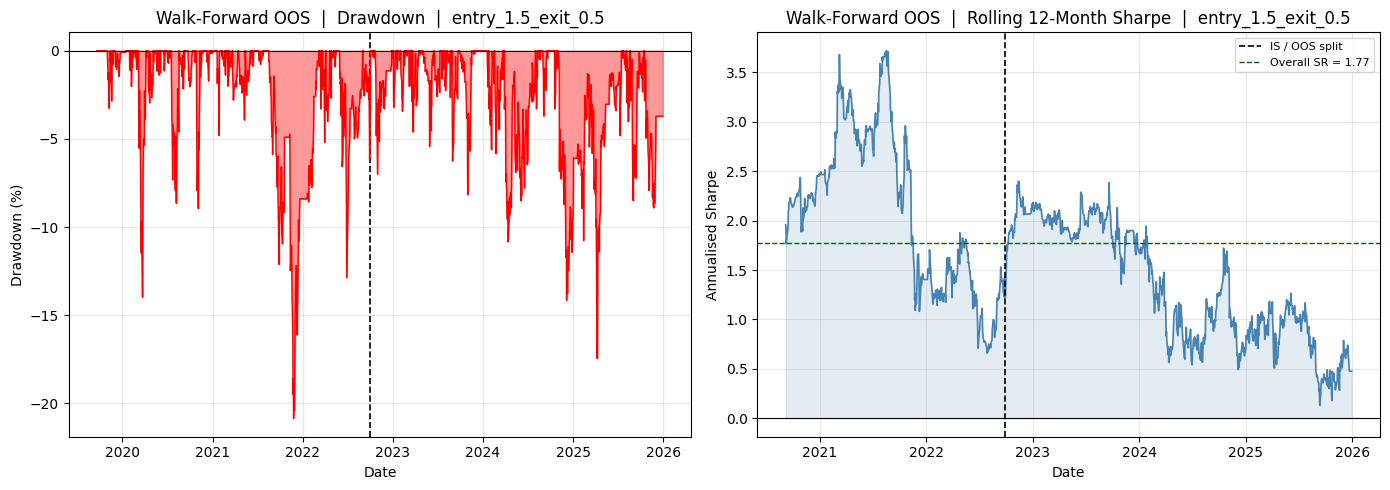

/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/rolling_outputs/WalkForward_entry_1.5_exit_0.5_cumulative_pnl.png


In [48]:
strategy_name = "entry_1.5_exit_0.5"

save_dir = PROJECT_ROOT / "outputs/rolling_outputs"
os.makedirs(save_dir, exist_ok=True)

rolling_ret = rolling_results[strategy_name]
rolling_cum = 100 * (1 + rolling_ret.fillna(0)).cumprod()
roll_sr     = rolling_sharpe(rolling_ret, window=252)
drawdown    = (rolling_cum - rolling_cum.cummax()) / rolling_cum.cummax() * 100

# Single Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_cum.index, rolling_cum, color="darkorange", lw=1.5, label="Walk-Forward OOS")
ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title(f"Walk-Forward Portfolio Cumulative PnL  |  {strategy_name}")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / f"WalkForward_{strategy_name}_cumulative_pnl.png", dpi=300, bbox_inches="tight")
plt.show()

# Side-by-side: Drawdown | Rolling Sharpe
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)


axes[0].fill_between(drawdown.index, drawdown, 0, alpha=0.4, color="red")
axes[0].axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
axes[0].plot(drawdown.index, drawdown, color="red", lw=1.0)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Walk-Forward OOS  |  Drawdown  |  {strategy_name}")
axes[0].set_ylabel("Drawdown (%)")
axes[0].set_xlabel("Date")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_sr.index, roll_sr, color="steelblue", lw=1.2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
axes[1].axhline(1.77, color="darkgreen", linestyle="--", lw=1.0, label="Overall SR = 1.77")
axes[1].fill_between(roll_sr.index, 0, roll_sr, where=roll_sr >= 0, alpha=0.15, color="steelblue")
axes[1].fill_between(roll_sr.index, 0, roll_sr, where=roll_sr <  0, alpha=0.15, color="red")
axes[1].set_title(f"Walk-Forward OOS  |  Rolling 12-Month Sharpe  |  {strategy_name}")
axes[1].set_ylabel("Annualised Sharpe")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_dir / f"WalkForward_{strategy_name}_drawdown_and_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

print(save_dir / f"WalkForward_{strategy_name}_cumulative_pnl.png")

A rolling 12-month Sharpe of 4 means that specific year the strategy was firing on all cylinders — the pairs were unusually mean-reverting, spreads were opening and closing cleanly, and the z-score signals were well-timed.

For your HK tech/commodity pairs, the most likely candidate windows would be something like:

2020–2021: COVID volatility caused large spread dislocations that snapped back hard — a pairs strategy's dream scenario
Late 2022–2023: HK tech cratered then recovered, which could have created strong mean-reversion in the cross-sector spreads
During those regimes, the spread moves were larger than usual but still mean-reverting, so the strategy earned its mean return on a lower relative volatility — which mechanically inflates the Sharpe.

This is actually an important thing to note in your report. A Sharpe of 4 in one regime and maybe 0.8 in another tells you the strategy is regime-dependent — it works better when there's elevated but mean-reverting volatility. When markets are trending or the pairs relationship breaks down, performance drops. The overall Sharpe of 1.77 is the blended average across both good and bad regimes.

You can verify this by looking at which dates the rolling Sharpe peaks — if it lines up with the COVID period or the 2022 HK tech crash/recovery, that confirms the regime story.

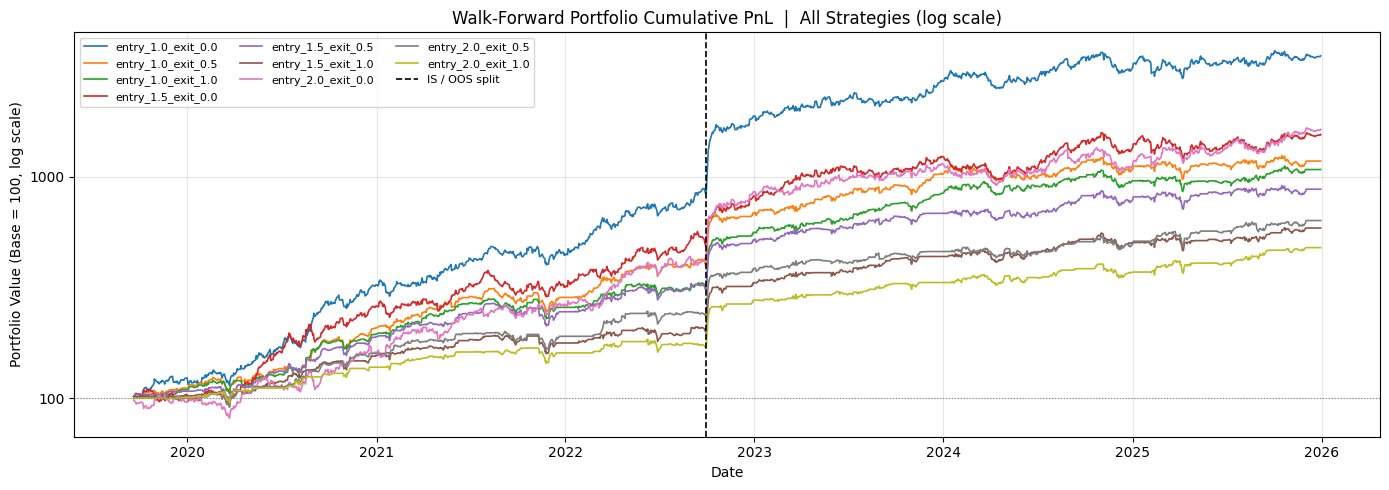

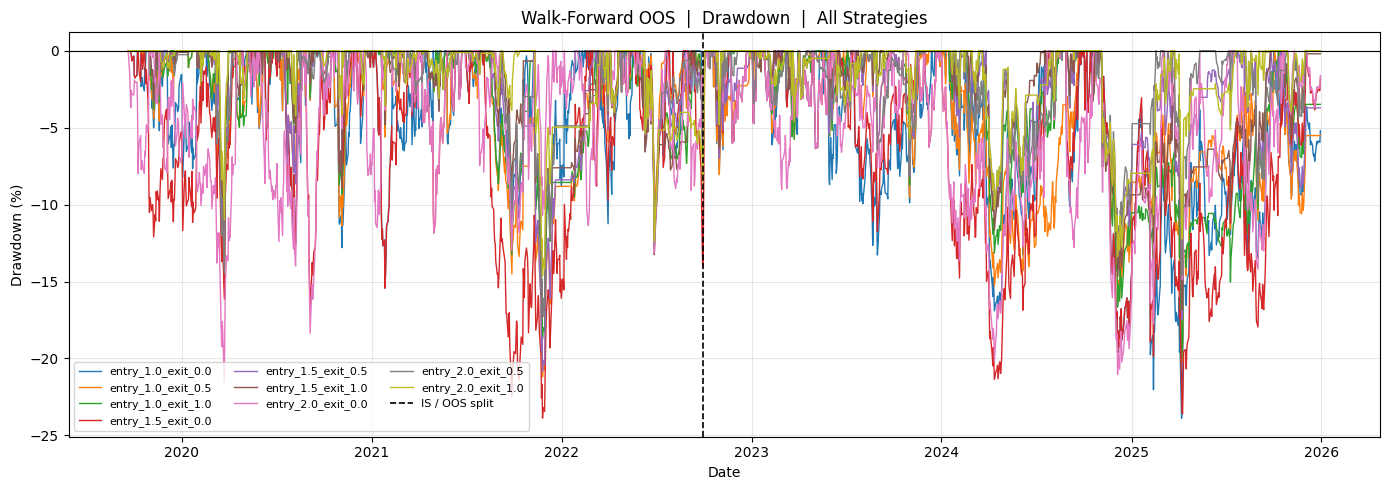

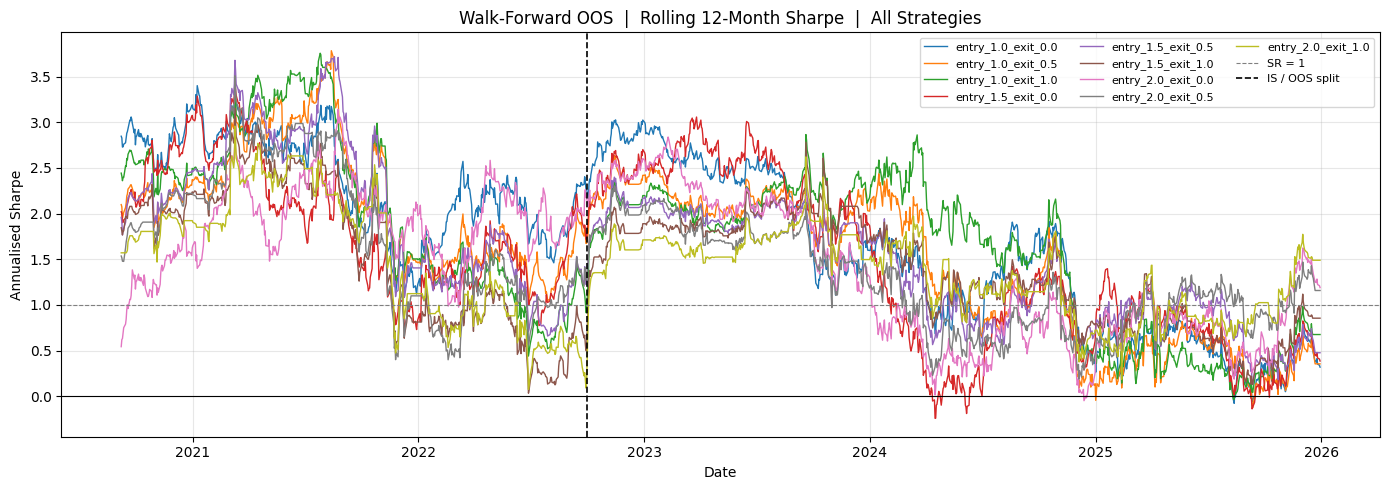

In [49]:
colors = plt.cm.tab10.colors

# Cum PnL
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    cum = 100 * (1 + ret.fillna(0)).cumprod()
    ax.plot(cum.index, cum, lw=1.2, color=colors[i], label=key)

ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title("Walk-Forward Portfolio Cumulative PnL  |  All Strategies (log scale)")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_cumulative_pnl.png", dpi=300, bbox_inches="tight")
plt.show()

# Drawdown
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    cum      = 100 * (1 + ret.fillna(0)).cumprod()
    drawdown = (cum - cum.cummax()) / cum.cummax() * 100
    ax.plot(drawdown.index, drawdown, lw=1.0, color=colors[i], label=key)

ax.axhline(0, color="black", lw=0.8)
ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.set_title("Walk-Forward OOS  |  Drawdown  |  All Strategies")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

# Sharpe
fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, ret) in enumerate(rolling_results.items()):
    roll_sr = rolling_sharpe(ret, window=252)
    ax.plot(roll_sr.index, roll_sr, lw=1.0, color=colors[i], label=key)

ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="grey", linestyle="--", lw=0.8, label="SR = 1")
ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.set_title("Walk-Forward OOS  |  Rolling 12-Month Sharpe  |  All Strategies")
ax.set_ylabel("Annualised Sharpe")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "WalkForward_All_Strategies_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Walk-forward backtest using the refined signal (dynamic z-score bands)
rolling_ret_refined = walk_forward_refined_backtest(
    dynamic_details = dynamic_details_full,
    weights         = weights,
    obs_cov         = 1.0,
    is_window       = 262,
    oos_step        = 63,
)

print(f"Refined walk-forward OOS observations : {len(rolling_ret_refined)}")
print(f"Date range : {rolling_ret_refined.index[0].date()} → {rolling_ret_refined.index[-1].date()}")

Refined walk-forward OOS observations : 1638
Date range : 2019-09-20 → 2025-12-30


# Performance metrics — Refined

In [51]:
rf_aligned          = rf_full.reindex(rolling_ret.index).ffill()
metrics             = performance_metrics(rolling_ret,         rf=rf_aligned, bootstrap_ci=True)

rf_aligned_refined  = rf_full.reindex(rolling_ret_refined.index).ffill()
metrics_refined     = performance_metrics(rolling_ret_refined, rf=rf_aligned_refined, bootstrap_ci=True)

pd.DataFrame(
    [metrics, metrics_refined],
    index=["Baseline Walk-Forward", "Refined Walk-Forward"]
)

pd.DataFrame(
    [metrics, metrics_refined],
    index=["Baseline Walk-Forward", "Refined Walk-Forward"]
)

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
Baseline Walk-Forward,0.1353,0.1283,"1.3699 [0.7050, 1.9860]",670.93,57.83,-21.16,1638
Refined Walk-Forward,0.1314,0.1244,"1.2316 [0.5215, 1.9091]",602.41,56.01,-25.28,1638


In [52]:
# For all z-entry and z-exit values
refined_rolling_results = {}

for e in entry_values:
    for x in exit_values:
        key = f"entry_{e}_exit_{x}"
        refined_rolling_results[key] = walk_forward_refined_backtest(
            dynamic_details = dynamic_details_full,
            weights         = weights,
            obs_cov         = 1.0,
            is_window       = 262,
            oos_step        = 63,
            exit_z          = x,
        )

baseline_metrics_all = {}
refined_metrics_all  = {}

for key in rolling_results:
    rf_b = rf_full.reindex(rolling_results[key].index).ffill()
    rf_r = rf_full.reindex(refined_rolling_results[key].index).ffill()
    baseline_metrics_all[key] = performance_metrics(rolling_results[key],         rf=rf_b)
    refined_metrics_all[key]  = performance_metrics(refined_rolling_results[key], rf=rf_r)

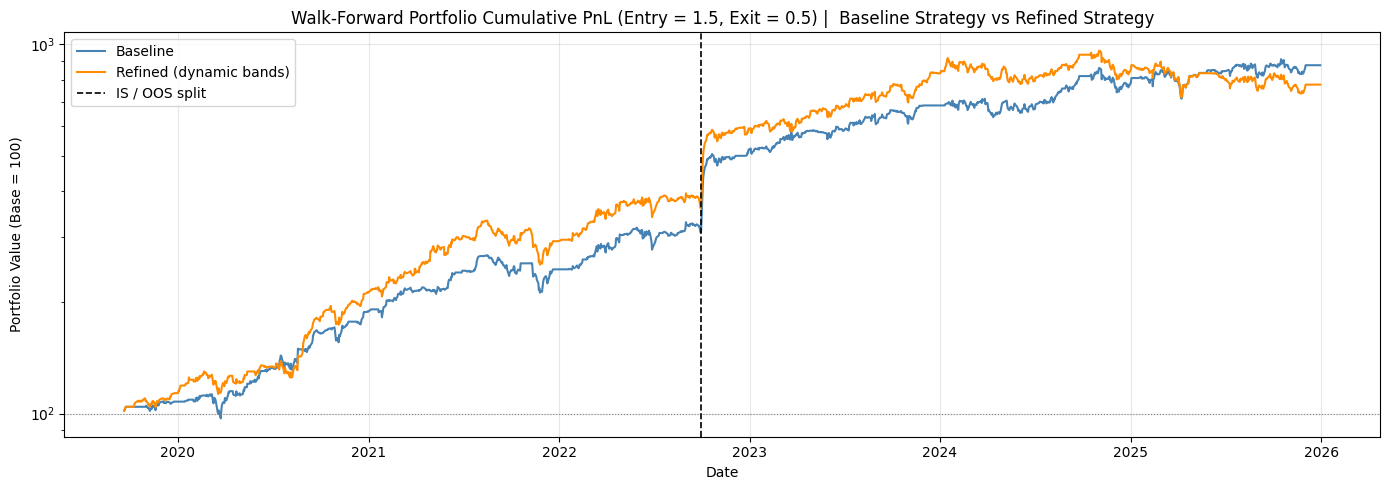

In [53]:
# Compare baseline vs refined walk-forward cumulative PnL
cum_baseline = 100 * (1 + rolling_ret.fillna(0)).cumprod()
cum_refined  = 100 * (1 + rolling_ret_refined.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum_baseline.index, cum_baseline, color="steelblue",  lw=1.5, label="Baseline")
ax.plot(cum_refined.index,  cum_refined,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")

# Log-Scaled PnL 
ax.set_yscale("log")
ax.set_title("Walk-Forward Portfolio Cumulative PnL (Entry = 1.5, Exit = 0.5) |  Baseline Strategy vs Refined Strategy")
ax.set_ylabel("Portfolio Value (Base = 100)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
for key in rolling_results:
    cum_baseline = 100 * (1 + rolling_results[key].fillna(0)).cumprod()
    cum_refined  = 100 * (1 + refined_rolling_results[key].fillna(0)).cumprod()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cum_baseline.index, cum_baseline, color="steelblue",  lw=1.5, label="Baseline")
    ax.plot(cum_refined.index,  cum_refined,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
    ax.axhline(100, color="grey", linestyle=":", lw=0.8)
    ax.axvline(is_df.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
    ax.set_yscale("log")
    ax.set_title(f"Walk-Forward PnL  |  {key}  |  Baseline vs Refined (log scale)")
    ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f"{key}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Saved {len(rolling_results)} plots to: {save_dir}")

Saved 9 plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/rolling_outputs


---

# Part D — Dynamic Pair Selection

# 10 — Dynamic Pair Selection Backtest (Option B)

**Research question addressed:** does *re-selecting* the pairs over time beat holding a
*static* set chosen once? This notebook implements a rolling **12-month formation /
3-month trading** walk-forward. In every formation window we re-run the Engle-Granger
cointegration test across all within-sector candidate pairs, keep every pair that
cointegrates at *p < 0.10* (the project threshold), rank by p-value, enforce **unique legs**
(a stock cannot anchor two pairs in the same period), and trade the survivors over the
next quarter with the same Kalman + z-score signal used throughout the project.

To isolate the effect of *selection* we run the **identical engine** in two modes over the
**same fold schedule, dates, costs and z-bands**:

- **Static selection** — the pairs are fixed once (the `data/portfolio` set).
- **Dynamic selection** — the pairs are re-chosen every quarter.

The *only* difference between the two curves is whether pairs are re-selected, so any
performance gap is attributable to dynamic selection rather than luck in stock-picking or
differences in the signal.

**No look-ahead:** selection uses only formation-window prices; the Kalman filter is causal
and re-fit per fold; transaction costs are charged on the full context and then sliced to
the trading window (matching `src/rolling_backtest.py`).

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.dynamic_pairs import (
    dynamic_pair_walk_forward,
    FORMATION_WINDOW,
    TRADING_PERIOD,
    SELECTION_ALPHA,
)
from src.backtest import performance_metrics
from src.rolling_backtest import rolling_sharpe
from src.config import ENTRY_Z, EXIT_Z, OBS_COV

## 1. Load the full-timeline price universe

We concatenate the in-sample and out-of-sample price frames so the rolling formation window can slide across the *entire* history. Candidate pairs are formed **within sector** (tech-tech, commodity-commodity), matching the project's methodology and the economic-link argument.

In [56]:
def _load(name):
    return pd.read_csv(PROJECT_ROOT / "data" / name, index_col=0, parse_dates=True)

df1_full = pd.concat([_load("df1_is"), _load("df1_oos")]).sort_index()   # tech
df2_full = pd.concat([_load("df2_is"), _load("df2_oos")]).sort_index()   # commodity

prices_by_sector = {"tech": df1_full, "commodity": df2_full}

# OOS split — everything after this date is genuine out-of-sample.
OOS_SPLIT = pd.Timestamp("2022-09-30")

rf_full = pd.concat([
    _load("rf_is"), _load("rf_oos")
]).sort_index()

print("Tech universe:      ", df1_full.shape[1], "tickers,",
      df1_full.index.min().date(), "->", df1_full.index.max().date())
print("Commodity universe: ", df2_full.shape[1], "tickers,",
      df2_full.index.min().date(), "->", df2_full.index.max().date())
print(f"Formation window = {FORMATION_WINDOW}d  |  Trading period = {TRADING_PERIOD}d  |  "
      f"selection alpha = {SELECTION_ALPHA}")

Tech universe:       14 tickers, 2015-01-01 -> 2025-12-31
Commodity universe:  36 tickers, 2015-01-01 -> 2025-12-01
Formation window = 252d  |  Trading period = 63d  |  selection alpha = 0.1


## 2. Static-selection benchmark (controlled variable)

The fixed pair set is the portfolio you selected once in the earlier pipeline. It is traded on the *same* rolling schedule so it shares the dynamic strategy's dates, costs and signal — the honest baseline.

In [57]:
portfolio = pd.read_csv(PROJECT_ROOT / "data/portfolio")

fixed_pairs = []
for p in portfolio["pair"]:
    y, x = [s.strip() for s in p.split(" vs ")]
    in_tech = y in df1_full.columns and x in df1_full.columns
    in_comm = y in df2_full.columns and x in df2_full.columns
    if in_tech or in_comm:
        fixed_pairs.append((y, x))
    else:
        print("Skipping fixed pair (ticker not in current data):", p)

print("Static pairs used:", fixed_pairs)

static_ret, static_log = dynamic_pair_walk_forward(
    prices_by_sector,
    fixed_pairs=fixed_pairs,
    entry_z=ENTRY_Z, exit_z=EXIT_Z, obs_cov=OBS_COV,
)
print("Static walk-forward:", len(static_ret), "days,",
      static_ret.index.min().date(), "->", static_ret.index.max().date())

Static pairs used: [('285 HK Equity', '3690 HK Equity'), ('1818 HK Equity', '1921 HK Equity'), ('2386 HK Equity', '386 HK Equity')]


Static walk-forward: 2583 days, 2015-12-21 -> 2025-11-12


## 3. Dynamic-selection strategy (Option B)

Same engine, but pairs are re-selected every quarter from the cointegration test on the trailing 12 months.

In [58]:
dynamic_ret, dynamic_log = dynamic_pair_walk_forward(
    prices_by_sector,
    fixed_pairs=None,                # None => re-select every fold
    formation_window=FORMATION_WINDOW,
    trading_period=TRADING_PERIOD,
    alpha=SELECTION_ALPHA,
    unique_legs=True,
    entry_z=ENTRY_Z, exit_z=EXIT_Z, obs_cov=OBS_COV,
)

n_folds = dynamic_log["fold"].nunique()
avg_pairs = dynamic_log.groupby("fold").size().mean()
print("Dynamic walk-forward:", len(dynamic_ret), "days,",
      dynamic_ret.index.min().date(), "->", dynamic_ret.index.max().date())
print(f"Folds: {n_folds}  |  avg pairs held per fold: {avg_pairs:.1f}")

Dynamic walk-forward: 2583 days, 2015-12-21 -> 2025-11-12
Folds: 41  |  avg pairs held per fold: 14.6


## 4. Headline comparison — out-of-sample metrics

We restrict both return streams to the common OOS window so the comparison is on genuinely unseen data, then compute the standard performance metrics (with bootstrapped Sharpe confidence intervals).

In [59]:
def to_oos(ret):
    return ret.loc[ret.index >= OOS_SPLIT]

rows = []
for label, ret in [("Static selection", static_ret), ("Dynamic selection", dynamic_ret)]:
    for scope, series in [("Full sample", ret), ("Out-of-sample", to_oos(ret))]:
        rf_aligned = rf_full.reindex(series.index).ffill()
        m = performance_metrics(series, rf=rf_aligned, bootstrap_ci=True)
        m["strategy"] = label
        m["scope"] = scope
        rows.append(m)

comparison = pd.DataFrame(rows).set_index(["scope", "strategy"]).sort_index()
comparison

avg_return (%)  avg_excess_return (%)  \
scope         strategy                                                   
Full sample   Dynamic selection          0.2224                 0.2158   
              Static selection           0.2325                 0.2330   
Out-of-sample Dynamic selection          0.2317                 0.2192   
              Static selection           0.2171                 0.2046   

                                        annualised_sharpe  total_pnl  \
scope         strategy                                                 
Full sample   Dynamic selection  4.1089  [3.6211, 4.6116]   28237.12   
              Static selection   2.2656  [1.7990, 2.7928]   28366.57   
Out-of-sample Dynamic selection  4.2034  [3.3494, 5.1656]     539.98   
              Static selection   2.0708  [1.1310, 3.0115]     428.64   

                                 hit_rate (%)  max_drawdown (%)  num_obs  
scope         strategy                                                    
Full sample   Dynamic selection         62.37            -10.43     2583  
              Static selection          58.50            -16.56     2583  
Out-of-sample Dynamic selection         63.64             -6.28      814  
              Static selection          58.60            -16.56      814

## 5. Cumulative PnL — Static vs Dynamic selection

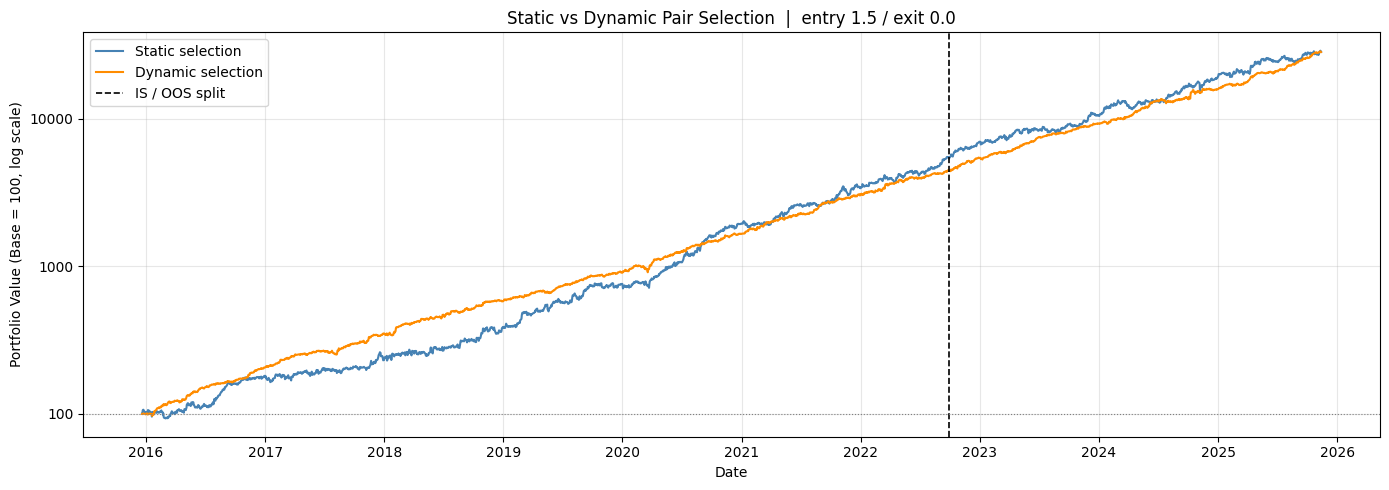

In [60]:
save_dir = PROJECT_ROOT / "outputs/dynamic_selection"
os.makedirs(save_dir, exist_ok=True)

static_cum  = 100 * (1 + static_ret.fillna(0)).cumprod()
dynamic_cum = 100 * (1 + dynamic_ret.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(static_cum.index,  static_cum,  color="steelblue", lw=1.5, label="Static selection")
ax.plot(dynamic_cum.index, dynamic_cum, color="darkorange", lw=1.5, label="Dynamic selection")
ax.axvline(OOS_SPLIT, color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title(f"Static vs Dynamic Pair Selection  |  entry {ENTRY_Z} / exit {EXIT_Z}")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / "static_vs_dynamic_cumulative_pnl.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Drawdown and rolling Sharpe

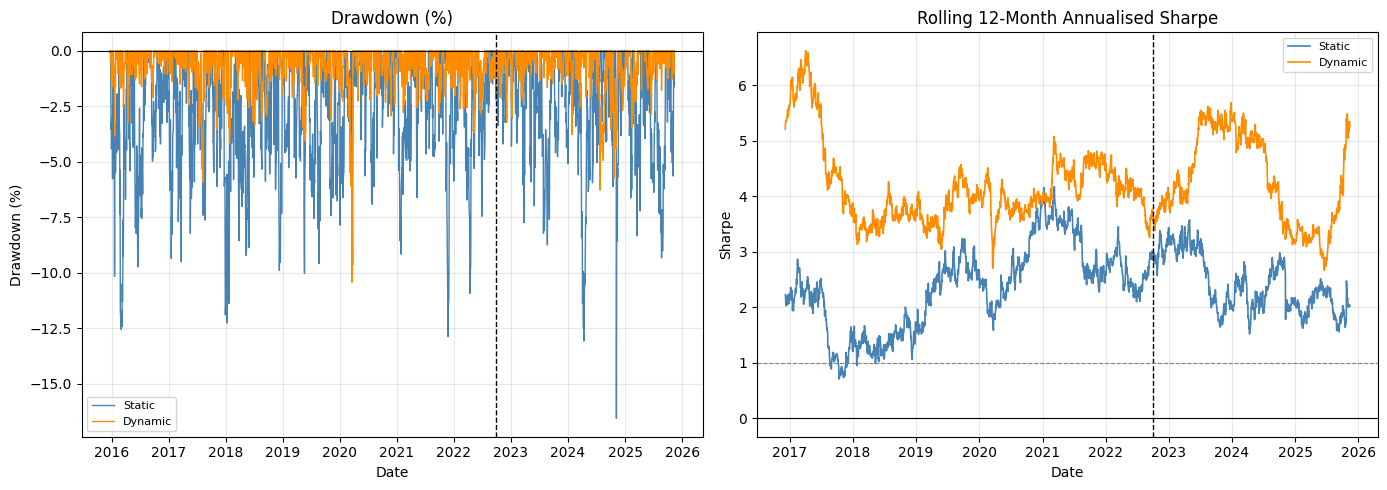

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ret, cum, color, label in [
    (static_ret,  static_cum,  "steelblue",  "Static"),
    (dynamic_ret, dynamic_cum, "darkorange", "Dynamic"),
]:
    dd = (cum - cum.cummax()) / cum.cummax() * 100
    axes[0].plot(dd.index, dd, color=color, lw=1.0, label=label)
    sr = rolling_sharpe(ret, window=252)
    axes[1].plot(sr.index, sr, color=color, lw=1.2, label=label)

for ax in axes:
    ax.axvline(OOS_SPLIT, color="black", linestyle="--", lw=1.0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Drawdown (%)"); axes[0].set_ylabel("Drawdown (%)"); axes[0].set_xlabel("Date")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(1, color="grey", linestyle="--", lw=0.8)
axes[1].set_title("Rolling 12-Month Annualised Sharpe"); axes[1].set_ylabel("Sharpe"); axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(save_dir / "static_vs_dynamic_drawdown_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. What did the dynamic strategy actually hold?

The selection log is the audit trail for the Analysis chapter: it shows *which* pairs were live in each quarter, their cointegration p-value at selection, and how much the roster churns over time — direct evidence of **cointegration decay** driving turnover in the pair set.

In [62]:
# Composition turnover: fraction of pairs that change from one fold to the next.
by_fold = dynamic_log.groupby("fold")["pair"].apply(set)
turnover = []
prev = None
for f, pairs in by_fold.items():
    if prev is not None:
        churn = 1 - len(pairs & prev) / len(pairs | prev)   # Jaccard distance
        turnover.append({"fold": f, "roster_turnover": churn, "n_pairs": len(pairs)})
    prev = pairs
turnover_df = pd.DataFrame(turnover)

print(f"Mean pairs held per fold : {by_fold.apply(len).mean():.1f}")
print(f"Mean roster turnover     : {turnover_df['roster_turnover'].mean():.1%} of the book replaced each quarter")

# Most frequently selected pairs across the whole history.
top_pairs = (dynamic_log["pair"].value_counts()
             .rename("times_selected").head(15).to_frame())
top_pairs

Mean pairs held per fold : 14.6
Mean roster turnover     : 91.7% of the book replaced each quarter


,times_selected
pair,
1378 HK Equity vs 2099 HK Equity,6
1787 HK Equity vs 1818 HK Equity,6
1277 HK Equity vs 3899 HK Equity,5
2386 HK Equity vs 3899 HK Equity,5
2883 HK Equity vs 467 HK Equity,5
1171 HK Equity vs 1277 HK Equity,5
1258 HK Equity vs 934 HK Equity,5
700 HK Equity vs 981 HK Equity,4
467 HK Equity vs 975 HK Equity,4


In [63]:
# Persist the audit trail for the dissertation appendix / further analysis.
dynamic_log.to_csv(save_dir / "dynamic_selection_log.csv", index=False)
turnover_df.to_csv(save_dir / "dynamic_roster_turnover.csv", index=False)
comparison.to_csv(save_dir / "static_vs_dynamic_metrics.csv")
print("Saved:")
for f in sorted(os.listdir(save_dir)):
    print("  ", save_dir / f)

Saved:
   /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/dynamic_selection/dynamic_roster_turnover.csv
   /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/dynamic_selection/dynamic_selection_log.csv
   /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/dynamic_selection/static_vs_dynamic_cumulative_pnl.png
   /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/dynamic_selection/static_vs_dynamic_drawdown_sharpe.png
   /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/dynamic_selection/static_vs_dynamic_metrics.csv


## 8. Notes & limitations (for the write-up)

- **Selection rule.** Every pair cointegrating at *p < 0.10* on the trailing 12 months is
  admitted (ranked by p-value, unique legs). Tightening `alpha` or capping with `top_n`
  in `dynamic_pair_walk_forward` yields a smaller, higher-conviction book — a natural
  robustness/sensitivity table.
- **Equal weighting.** Pairs held in a fold are equal-weighted. Spreads are in raw
  price-difference units (the project's existing `spread_t.diff()` convention), so pairs on
  higher-priced names contribute larger swings. Because *both* Static and Dynamic modes run
  through the identical engine, this scaling is common to both and does not bias the
  comparison — but it is worth a sentence in Limitations, alongside the volatility-scaled
  weighting you could add as Future Work.
- **Cointegration decay.** The roster-turnover series is the empirical hook for the decay
  argument: pairs drop out of the book precisely when their trailing-window cointegration
  breaks, which a static selection cannot react to.